In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from mne_bids import BIDSPath, read_raw_bids
from matplotlib_venn import venn2,venn2_circles
from tqdm import tqdm

In [2]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')                    

Using notebook 3d backend.


In [3]:
import pandas as pd
import numpy as np
from mne_bids import BIDSPath
from tqdm import tqdm

task = [
    'PhonemeSequence',
    'LexicalNoDelay',
    'LexicalDelay',
    'PictureNaming',
    'SentenceRep',
]
ref = 'bipolar'
atlas = 'hammers'

hga_paths = []
for t in task:
    hga_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})({atlas})',
            datatype='HGA',
            suffix='time',
            check=False,
        ).match()
    )

if not hga_paths:
    raise FileNotFoundError(
        f'No time CSVs under results/{{task}}({ref})({atlas})/ for tasks={task}'
    )

HGAs = pd.concat(
    [pd.read_csv(path) for path in tqdm(hga_paths, desc='load time')],
    ignore_index=True,
)

HGAs.loc[HGAs.phase == 'Resp', 'phase'] = 'Response'
HGAs.loc[HGAs.phase == 'Audio', 'phase'] = 'Stimulus'
HGAs['phase'] = HGAs['phase'].str.lower()

# Hammers ROI groupings (vizpub/fig1 convention)
HGAs.loc[HGAs.roi == 'PrG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'PoG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'Subcentral', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'STGp', 'roi'] = 'STG'
HGAs.loc[HGAs.roi == 'STGa', 'roi'] = 'STG'
HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'

print(f'Loaded {len(hga_paths)} files, {len(HGAs):,} rows')
HGAs.head()

load time: 100%|██████████| 1212/1212 [00:23<00:00, 51.30it/s]


Loaded 1212 files, 9,037,696 rows


,time,channel,value,mask,subject,description,task,phase,modality,label,...,y1_template,z1_template,x2_template,y2_template,z2_template,contact_1,contact_2,contact_1_label,contact_2_label,mix
0,-1.000000,D0019_RLOS2-3,-0.050144,False,D0019,Repeat,PhonemeSequence,delay,sound,PL supramarginal gyrus R,...,-35.1426,37.1628,51.1196,-26.6596,38.1841,RLOS2,RLOS3,0,0,False
1,-0.992188,D0019_RLOS2-3,-0.096867,False,D0019,Repeat,PhonemeSequence,delay,sound,PL supramarginal gyrus R,...,-35.1426,37.1628,51.1196,-26.6596,38.1841,RLOS2,RLOS3,0,0,False
2,-0.984375,D0019_RLOS2-3,-0.125324,False,D0019,Repeat,PhonemeSequence,delay,sound,PL supramarginal gyrus R,...,-35.1426,37.1628,51.1196,-26.6596,38.1841,RLOS2,RLOS3,0,0,False
3,-0.976562,D0019_RLOS2-3,-0.123982,False,D0019,Repeat,PhonemeSequence,delay,sound,PL supramarginal gyrus R,...,-35.1426,37.1628,51.1196,-26.6596,38.1841,RLOS2,RLOS3,0,0,False
4,-0.968750,D0019_RLOS2-3,-0.100060,False,D0019,Repeat,PhonemeSequence,delay,sound,PL supramarginal gyrus R,...,-35.1426,37.1628,51.1196,-26.6596,38.1841,RLOS2,RLOS3,0,0,False


In [4]:
def insula_mask(df, atlas):
    """Boolean mask for insula electrodes (aparc: INS/Insula; hammers: pure AIC/PIC)."""
    if atlas in ('aparc', 'aparc2009s'):
        return df['roi'].isin({'INS', 'Insula'})
    mask = df['roi'].isin({'AIC', 'PIC'})
    if 'mix' in df.columns:
        mask = mask & ~df['mix'].fillna(False).astype(bool)
    return mask


def filter_qc_electrodes(spatial):
    """Drop missing-annotation (label==0) and composite bipolar (mix) electrodes."""
    spatial = spatial.copy()
    if 'mix' in spatial.columns:
        spatial = spatial[~spatial['mix'].fillna(False).astype(bool)]
    if 'label' in spatial.columns:
        label_num = pd.to_numeric(spatial['label'], errors='coerce')
        spatial = spatial[~(label_num == 0)]
    return spatial


# 4-phase windows (fig1 delay/response; nmf-style pre/post for stimulus/go)
PHASE_CONFIGS = {
    'stimulus': {'phase': 'stimulus', 'time_min': -0.5, 'time_max': 1.0},
    'delay':    {'phase': 'delay',    'time_min': 0.0,   'time_max': 1.0},
    'go':       {'phase': 'go',       'time_min': -0.5, 'time_max': 1.0},
    'response': {'phase': 'response', 'time_min': -0.5, 'time_max': 0.5},
}

insula_ch = (
    HGAs.loc[insula_mask(HGAs, atlas)]
    .groupby('channel')
    .agg({'roi': 'first', 'mix': 'first', 'label': 'first', 'hemi': 'first'})
    .reset_index()
)
insula_ch = filter_qc_electrodes(insula_ch)
qc_channels = set(insula_ch['channel'])

print(
    f'Hammers insula (bilateral, QC): {len(qc_channels)} channels | '
    f"AIC={insula_ch.loc[insula_ch.roi=='AIC','channel'].nunique()} | "
    f"PIC={insula_ch.loc[insula_ch.roi=='PIC','channel'].nunique()}"
)
insula_ch.groupby(['roi', 'hemi']).size()

Hammers insula (bilateral, QC): 246 channels | AIC=167 | PIC=79


roi  hemi
AIC  L       107
     R        60
PIC  L        47
     R        32
dtype: int64

## NMF on Hammers insula — 4-phase concat

**Electrodes:** Hammers atlas, pure `AIC`/`PIC`, `mix==False`, optional QC (`label!=0`). Bilateral (L+R).

**Phases concatenated** (mean across tasks per channel×time, then demean along time within each phase):
| Phase | Window (s) | Notes |
|-------|------------|-------|
| stimulus | −0.5 to 1 | pre/post onset (nmf.ipynb style) |
| delay | 0 to 1 | fig1 delay window |
| go | −0.5 to 1 | pre/post go cue |
| response | −0.5 to 0.5 | fig1 response window |

**Workflow:** (1) model-selection metrics justify **k=2**; (2) k=2 insula brain maps; (3) optional parameter grid under `../tmp/nmf/`.


In [5]:
import xarray as xr
from sklearn.decomposition import NMF


def channel_metadata(df):
    return (
        df.groupby('channel')
        .agg({
            'x': 'first', 'y': 'first', 'z': 'first', 'roi': 'first',
            'label': 'first', 'hemi': 'first', 'subject': 'first',
        })
        .reset_index()
    )


def significant_channels_union(df, phase_configs):
    """Union of mask==True channels across all phase/time windows."""
    channels = set()
    sig = df['mask'].astype(bool)
    for cfg in phase_configs.values():
        in_window = (
            (df['phase'] == cfg['phase'])
            & (df['time'] > cfg['time_min'])
            & (df['time'] < cfg['time_max'])
            & sig
        )
        channels.update(df.loc[in_window, 'channel'].unique())
    return channels


def prepare_subset(df, *, atlas='hammers', description='Repeat', sig_mode='sig_union', phase_configs=PHASE_CONFIGS):
    """Filter to sound-modality insula rows for NMF.

    atlas: 'hammers' | 'aparc' (post-classification AIC/PIC)
    sig_mode: 'all_insula' | 'sig_union' (any task) | 'sig_per_phase' (mask in any phase window)
    description: 'Repeat' or 'all'
    """
    sub = df[(df.modality == 'sound') & insula_mask(df, atlas)].copy()
    if description == 'Repeat':
        sub = sub[sub.description == 'Repeat']

    meta = filter_qc_electrodes(channel_metadata(sub))
    sub = sub[sub.channel.isin(meta.channel)]

    if sig_mode == 'all_insula':
        keep = set(meta.channel)
    elif sig_mode == 'sig_union':
        sub['significance'] = sub.groupby(['task', 'channel'])['mask'].transform('any')
        keep = set(sub.loc[sub.significance, 'channel'].unique())
    elif sig_mode == 'sig_per_phase':
        keep = significant_channels_union(sub, phase_configs)
    else:
        raise ValueError(sig_mode)

    sub = sub[sub.channel.isin(keep)]
    meta = meta[meta.channel.isin(keep)]
    return sub, meta


def build_phase_xarray(df, phase, time_min, time_max):
    stage = (
        df[(df.phase == phase) & (df.time > time_min) & (df.time < time_max)]
        .groupby(['channel', 'time'])['value']
        .mean()
        .to_xarray()
    )
    return stage - stage.mean(dim='time')


def build_concat_stage(subset, phase_configs=PHASE_CONFIGS):
    stages, time_vectors, phase_names = [], [], []
    for name, cfg in phase_configs.items():
        stage = build_phase_xarray(
            subset, cfg['phase'], cfg['time_min'], cfg['time_max']
        )
        stages.append(stage)
        time_vectors.append(stage.time.values)
        phase_names.append(name)

    concat_stage = xr.concat(stages, dim='time').fillna(0)
    valid_channels = concat_stage.dropna(dim='channel', how='any').channel.values
    concat_stage = concat_stage.sel(channel=valid_channels)
    meta = channel_metadata(subset)
    meta = (
        meta[meta.channel.isin(valid_channels)]
        .set_index('channel')
        .loc[valid_channels]
        .reset_index()
    )
    return concat_stage, time_vectors, phase_names, meta


def preprocess_for_nmf(data_matrix, clip_percentile=None, min_shift=True):
    X = data_matrix.copy()
    if clip_percentile is not None:
        lo, hi = np.percentile(X, clip_percentile)
        X = np.clip(X, lo, hi)
    if min_shift:
        X = X - X.min()
    return X


def fit_nmf(concat_stage, *, n_components=2, clip_percentile=(1, 99), random_state=42):
    data_matrix = preprocess_for_nmf(
        concat_stage.values,
        clip_percentile=clip_percentile,
        min_shift=True,
    )
    nmf = NMF(n_components=n_components, random_state=random_state, max_iter=500)
    W = nmf.fit_transform(data_matrix)
    H = nmf.components_
    return W, H, nmf


def assign_components(W):
    comp = W.argmax(axis=1)
    weight = W[np.arange(len(W)), comp]
    return comp, weight

## Model selection: justify k=2

Standard NMF diagnostics on the **best prior settings** (`clip=None`, `sig=sig_union`, `desc=all`). Sweeps `k=1…K_MAX` and records reconstruction error (Frobenius / `reconstruction_err_`), silhouette on the channel loading matrix **W**, and explained variance ratio. Plots saved to `../tmp/nmf/`.


In [6]:
# --- k selection (configurable best-settings run) ---
from IPython.display import display
from sklearn.metrics import silhouette_score

OUTPUT_DIR = Path('../tmp/nmf')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

K_MAX = 6
K_RANGE = range(1, K_MAX + 1)
BEST_CLIP = None          # prior grid winner
BEST_SIG = 'sig_union'
BEST_DESC = 'all'

subset_k, _ = prepare_subset(HGAs, description=BEST_DESC, sig_mode=BEST_SIG)
concat_k, time_vectors_k, phase_names_k, meta_k = build_concat_stage(subset_k)
data_k = preprocess_for_nmf(concat_k.values, clip_percentile=BEST_CLIP)
n_channels, n_time = data_k.shape
print(f'k-selection data: {n_channels} channels × {n_time} timepoints | clip={BEST_CLIP} sig={BEST_SIG} desc={BEST_DESC}')

k_rows = []
nmf_by_k = {}
for k in K_RANGE:
    if k > n_channels:
        print(f'  skip k={k} (> n_channels)')
        continue
    nmf_k = NMF(n_components=k, random_state=42, max_iter=500)
    W_k = nmf_k.fit_transform(data_k)
    H_k = nmf_k.components_
    recon = float(nmf_k.reconstruction_err_)
    frob = float(np.linalg.norm(data_k - W_k @ H_k, 'fro'))
    total_var = float(np.sum(data_k ** 2))
    explained = float(1.0 - (frob ** 2) / total_var) if total_var > 0 else np.nan
    comp_k, _ = assign_components(W_k) if k > 1 else (np.zeros(len(W_k), dtype=int), W_k[:, 0])
    sil_w = float(silhouette_score(W_k, comp_k)) if k > 1 else np.nan
    xyz = meta_k[['x', 'y', 'z']].values
    sil_xyz = float(silhouette_score(xyz, comp_k)) if k > 1 else np.nan
    k_rows.append(dict(
        k=k, reconstruction_err=recon, frobenius_err=frob,
        explained_var_ratio=explained,
        silhouette_W=sil_w, silhouette_xyz=sil_xyz,
        n_channels=n_channels, n_timepoints=n_time,
        clip=str(BEST_CLIP), sig=BEST_SIG, desc=BEST_DESC,
    ))
    nmf_by_k[k] = dict(W=W_k, H=H_k, nmf=nmf_k, component=comp_k)
    print(f'  k={k}: recon={recon:.4f} sil_W={sil_w:.3f} sil_xyz={sil_xyz:.3f} expl_var={explained:.3f}')

k_metrics = pd.DataFrame(k_rows)
k_tag = f'kselect_clip-none_sig-{BEST_SIG}_desc-{BEST_DESC}'
k_metrics.to_csv(OUTPUT_DIR / f'{k_tag}_metrics.csv', index=False)
display(k_metrics.round(4))


k-selection data: 216 channels × 636 timepoints | clip=None sig=sig_union desc=all
  k=1: recon=63.8650 sil_W=nan sil_xyz=nan expl_var=0.990
  k=2: recon=44.3022 sil_W=0.869 sil_xyz=0.074 expl_var=0.995
  k=3: recon=34.6617 sil_W=0.334 sil_xyz=-0.018 expl_var=0.997
  k=4: recon=31.2650 sil_W=0.652 sil_xyz=-0.387 expl_var=0.998


/hpc/home/ns458/miniconda3/envs/ieeg/lib/python3.11/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(
/hpc/home/ns458/miniconda3/envs/ieeg/lib/python3.11/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


  k=5: recon=28.4665 sil_W=0.622 sil_xyz=-0.466 expl_var=0.998
  k=6: recon=27.1847 sil_W=0.559 sil_xyz=-0.346 expl_var=0.998


,k,reconstruction_err,frobenius_err,explained_var_ratio,silhouette_W,silhouette_xyz,n_channels,n_timepoints,clip,sig,desc
0,1,63.8650,63.8650,0.9903,NaN,NaN,216,636,None,sig_union,all
1,2,44.3022,44.3022,0.9953,0.8692,0.0736,216,636,None,sig_union,all
2,3,34.6617,34.6617,0.9971,0.3339,-0.0184,216,636,None,sig_union,all
3,4,31.2650,31.2650,0.9977,0.6519,-0.3874,216,636,None,sig_union,all
4,5,28.4665,28.4665,0.9981,0.6216,-0.4663,216,636,None,sig_union,all
5,6,27.1847,27.1847,0.9982,0.5592,-0.3464,216,636,None,sig_union,all


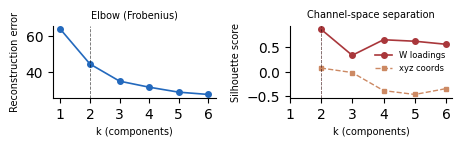

Saved ../tmp/nmf/kselect_clip-none_sig-sig_union_desc-all_model_selection.png


In [7]:
# --- Elbow + silhouette vs k ---
fig, axes = plt.subplots(1, 2, figsize=(12 * cm, 4 * cm))
ks = k_metrics['k'].values

axes[0].plot(ks, k_metrics['reconstruction_err'], 'o-', color=blue, lw=1.2, ms=4)
axes[0].axvline(2, color='k', ls='--', lw=0.6, alpha=0.6)
axes[0].set_xlabel('k (components)', fontsize=fontsize)
axes[0].set_ylabel('Reconstruction error', fontsize=fontsize)
axes[0].set_title('Elbow (Frobenius)', fontsize=fontsize)
axes[0].set_xticks(ks)
sns.despine(ax=axes[0])

axes[1].plot(ks, k_metrics['silhouette_W'], 'o-', color=red, lw=1.2, ms=4, label='W loadings')
axes[1].plot(ks, k_metrics['silhouette_xyz'], 's--', color=orange, lw=1.0, ms=3, label='xyz coords')
axes[1].axvline(2, color='k', ls='--', lw=0.6, alpha=0.6)
best_k = int(k_metrics.loc[k_metrics['silhouette_W'].idxmax(), 'k']) if k_metrics['silhouette_W'].notna().any() else 2
axes[1].axvline(best_k, color=red, ls=':', lw=0.6, alpha=0.5)
axes[1].set_xlabel('k (components)', fontsize=fontsize)
axes[1].set_ylabel('Silhouette score', fontsize=fontsize)
axes[1].set_title('Channel-space separation', fontsize=fontsize)
axes[1].set_xticks(ks)
axes[1].legend(fontsize=fontsize - 1, frameon=False)
sns.despine(ax=axes[1])

plt.tight_layout()
fig.savefig(OUTPUT_DIR / f'{k_tag}_model_selection.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved {OUTPUT_DIR / f"{k_tag}_model_selection.png"}')


### k-selection conclusion

For `clip=None`, `sig=sig_union`, `desc=all` (216 channels × 636 timepoints):

| k | recon err | sil(W) | expl. var |
|---|-----------|--------|----------|
| 1 | 63.9 | — | 0.990 |
| **2** | **44.3** | **0.869** | **0.995** |
| 3 | 34.7 | 0.334 | 0.997 |
| 4 | 31.3 | 0.652 | 0.998 |
| 5 | 28.5 | 0.622 | 0.998 |
| 6 | 27.2 | 0.559 | 0.998 |

- **Reconstruction error** drops sharply from k=1→2 (Δ≈19.6) with diminishing returns at k≥3 (elbow near **k=2**).
- **Silhouette on W** peaks strongly at **k=2** (0.87); k≥3 scores are much lower on W loadings (xyz silhouette is weak for all k).
- Explained variance rises only marginally beyond k=2 (+0.003 from k=2→6).

**Recommendation: k=2** is supported by standard NMF model-selection metrics (elbow + silhouette), independent of Hammers AIC/PIC agreement. AIC/PIC crosstabs remain a biological sanity check, not the primary k criterion.


## k=2 insula brain maps

> **Run on a compute node** (`srun` / Slurm): MNE `Brain` + PyVista rendering is slow and needs off-login resources. Uses `cvs_avg35_inMNI152` pial surface and insula zoom views (same convention as `viz/fig1.ipynb` Panel B / `vizpub/fig1.ipynb`).

Hard **argmax** component labels can look like k=1 when one cluster is small (e.g. ~11 vs ~205 channels), even when k=2 is justified statistically. These maps visualize **graded NMF loadings**:

- **Color** = dominant component (argmax on **W**).
- **Sphere size** ∝ loading strength (normalized across electrodes).

**Panel A (main):** size = loading on the dominant component (how strongly an electrode expresses its winning factor).

**Panel B (optional):** same colors, size = loading on the *non-dominant* component (highlights mixed / transitional electrodes).

A Hammers **AIC/PIC** reference map uses fixed marker size. Figures saved under `../tmp/nmf/` (suffix `_brain_nmf_weighted.png`).


NMF k=2 hard assignment counts: {0: 11, 1: 205}
Dominant loading: min=0.810 med=0.924 max=4.531
Dominance ratio (dom/sum W): min=0.501 med=0.763 max=1.000
  electrodes with dominance ratio < 0.55: 9 (4.2%)
  electrodes with dominance ratio < 0.6: 18 (8.3%)
  electrodes with dominance ratio < 0.7: 48 (22.2%)
  electrodes with dominance ratio < 0.8: 154 (71.3%)
Reading labels from parcellation...


   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/rh.aparc.a2009s.annot


2026-07-13 20:33:06.536 (  34.829s) [    7F377D5B0740]vtkXOpenGLRenderWindow.:1416  WARN| bad X server connection. DISPLAY=
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-13 20:33:06.590 (  34.882s) [    7F377D5B0740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x23cf53d0): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl

Saved ../tmp/nmf/k2_clip-none_sig-sig_union_desc-all_brain_nmf_weighted.png


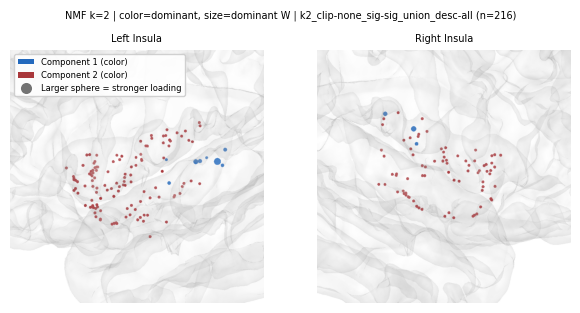

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-13 20:33:08.850 (  37.143s) [    7F377D5B0740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x2c0989c0): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/car

Saved ../tmp/nmf/k2_clip-none_sig-sig_union_desc-all_brain_nmf_minor_weight.png


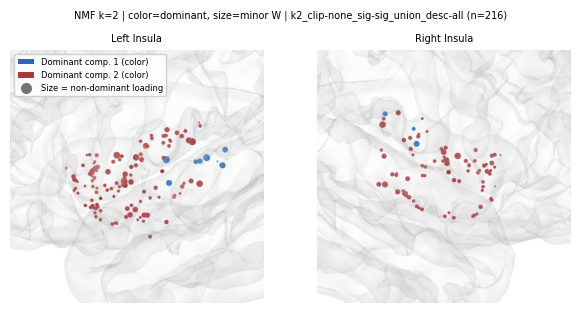

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-13 20:33:10.684 (  38.976s) [    7F377D5B0740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0xbbdab30): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card

Saved ../tmp/nmf/k2_clip-none_sig-sig_union_desc-all_brain_hammers.png


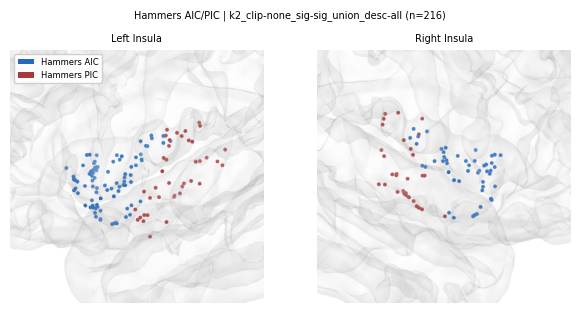

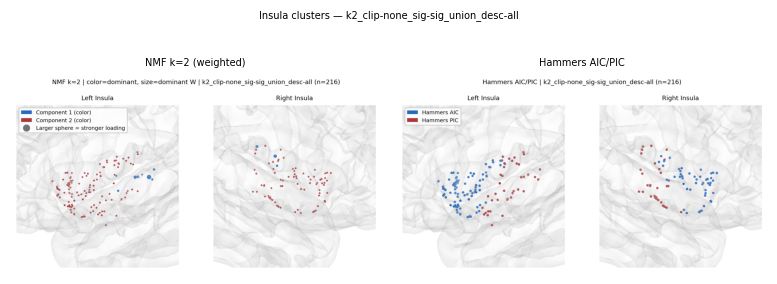

Saved ../tmp/nmf/k2_clip-none_sig-sig_union_desc-all_brain_sidebyside.png


: 

In [ ]:
# --- Insula zoom brain plots (compute node) ---
import os
os.environ.setdefault('PYVISTA_OFF_SCREEN', 'true')
import pyvista as pv
from mne.viz import Brain
from scipy.spatial import cKDTree
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

FS_SUBJECT = 'cvs_avg35_inMNI152'
BEST_K = 2
best_tag = f'k{BEST_K}_clip-none_sig-{BEST_SIG}_desc-{BEST_DESC}'
WEIGHT_SIZE_MIN, WEIGHT_SIZE_MAX = 6, 22

W2 = nmf_by_k[BEST_K]['W']
H2 = nmf_by_k[BEST_K]['H']


def nmf_k2_loadings(W):
    """Dominant/minor component indices and raw loadings for k=2."""
    comp = W.argmax(axis=1)
    minor = 1 - comp
    dom_w = W[np.arange(len(W)), comp]
    minor_w = W[np.arange(len(W)), minor]
    total = W.sum(axis=1)
    dom_ratio = dom_w / np.maximum(total, 1e-12)
    return comp, dom_w, minor_w, dom_ratio


def weight_to_point_sizes(w, size_min=WEIGHT_SIZE_MIN, size_max=WEIGHT_SIZE_MAX):
    w = np.asarray(w, dtype=float)
    if len(w) == 0:
        return w
    w_max = float(w.max())
    if w_max <= 0:
        return np.full(len(w), 0.5 * (size_min + size_max))
    return size_min + (size_max - size_min) * (w / w_max)


comp2, dom_w2, minor_w2, dom_ratio2 = nmf_k2_loadings(W2)
plot_meta = meta_k.copy()
plot_meta['component'] = comp2
plot_meta['weight_dom'] = dom_w2
plot_meta['weight_minor'] = minor_w2
plot_meta['dom_ratio'] = dom_ratio2
plot_meta['size_dom'] = weight_to_point_sizes(dom_w2)
plot_meta['size_minor'] = weight_to_point_sizes(minor_w2)

n_comp = pd.Series(comp2).value_counts().sort_index()
print('NMF k=2 hard assignment counts:', n_comp.to_dict())
print(
    f'Dominant loading: min={dom_w2.min():.3f} med={np.median(dom_w2):.3f} '
    f'max={dom_w2.max():.3f}'
)
print(
    f'Dominance ratio (dom/sum W): min={dom_ratio2.min():.3f} '
    f'med={np.median(dom_ratio2):.3f} max={dom_ratio2.max():.3f}'
)
for thr in (0.55, 0.6, 0.7, 0.8):
    n_below = int((dom_ratio2 < thr).sum())
    print(f'  electrodes with dominance ratio < {thr}: {n_below} ({100 * n_below / len(dom_ratio2):.1f}%)')

labels = mne.read_labels_from_annot(
    subject=FS_SUBJECT, parc='aparc.a2009s',
    surf_name='pial', hemi='both', subjects_dir=recon_dir,
)
INSULA_PATTERNS = [
    'G_insular_short', 'G_Ins_lg_and_S_cent_ins',
    'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup',
]

lh_pial_coords, _ = mne.read_surface(f'{recon_dir}/{FS_SUBJECT}/surf/lh.pial')
rh_pial_coords, _ = mne.read_surface(f'{recon_dir}/{FS_SUBJECT}/surf/rh.pial')
lh_tree = cKDTree(lh_pial_coords)
rh_tree = cKDTree(rh_pial_coords)


def _insula_center(hemi, pial_coords):
    vertices = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in INSULA_PATTERNS):
            vertices.extend(lab.vertices)
    return pial_coords[vertices].mean(axis=0) if vertices else None


lh_insula_center = _insula_center('lh', lh_pial_coords)
rh_insula_center = _insula_center('rh', rh_pial_coords)


def _make_insula_brain(hemi):
    return Brain(
        FS_SUBJECT, subjects_dir=recon_dir, surf='pial',
        hemi=hemi, background='white', show=False,
        cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(800, 800),
    )


def _project_to_pial(cord, tree, pial_coords):
    _, indices = tree.query(cord)
    return pial_coords[indices]


def _add_electrodes_fixed(brain, coords_proj, colors, sizes=None, point_size=12):
    if sizes is None:
        sizes = np.full(len(coords_proj), point_size)
    else:
        sizes = np.asarray(sizes, dtype=float)
    for pt, color, sz in zip(coords_proj, colors, sizes):
        cloud = pv.PolyData(pt.reshape(1, 3))
        brain._renderer.plotter.add_mesh(
            cloud, render_points_as_spheres=True,
            point_size=float(sz), color=color, lighting=False,
        )


def plot_insula_electrode_panel(
    plot_df,
    *,
    colors,
    sizes=None,
    title,
    legend_handles=None,
    save_path=None,
):
    if plot_df.empty:
        print(f'Skip plot (no electrodes): {title}')
        return
    cord = plot_df[['x', 'y', 'z']].values
    mask_lh = cord[:, 0] < 0
    mask_rh = cord[:, 0] > 0
    size_arr = None if sizes is None else np.asarray(sizes)

    lh_brain = _make_insula_brain('lh')
    rh_brain = _make_insula_brain('rh')

    if mask_lh.any():
        lh_proj = _project_to_pial(cord[mask_lh], lh_tree, lh_pial_coords)
        lh_sizes = None if size_arr is None else size_arr[mask_lh]
        _add_electrodes_fixed(lh_brain, lh_proj, np.asarray(colors)[mask_lh], sizes=lh_sizes)
    if mask_rh.any():
        rh_proj = _project_to_pial(cord[mask_rh], rh_tree, rh_pial_coords)
        rh_sizes = None if size_arr is None else size_arr[mask_rh]
        _add_electrodes_fixed(rh_brain, rh_proj, np.asarray(colors)[mask_rh], sizes=rh_sizes)

    lh_brain.show_view(azimuth=180, elevation=90, distance=180, focalpoint=lh_insula_center)
    rh_brain.show_view(azimuth=0, elevation=90, distance=180, focalpoint=rh_insula_center)

    fig, axes = plt.subplots(1, 2, figsize=(16 * cm, 8 * cm))
    axes[0].imshow(lh_brain.screenshot(mode='rgb'))
    axes[0].axis('off')
    axes[0].set_title('Left Insula', fontsize=fontsize)
    axes[1].imshow(rh_brain.screenshot(mode='rgb'))
    axes[1].axis('off')
    axes[1].set_title('Right Insula', fontsize=fontsize)
    if legend_handles:
        axes[0].legend(handles=legend_handles, loc='upper left', fontsize=fontsize - 1, framealpha=0.9)
    plt.suptitle(f'{title} (n={len(plot_df)})', fontsize=fontsize)
    lh_brain.close()
    rh_brain.close()
    plt.tight_layout()
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f'Saved {save_path}')
    plt.show()


NMF_COMP_COLORS = {0: blue, 1: red}
HAMMERS_ROI_COLORS = {'AIC': blue, 'PIC': red}
nmf_colors = [NMF_COMP_COLORS[c] for c in plot_meta['component']]
hammers_colors = [HAMMERS_ROI_COLORS.get(r, 'gray') for r in plot_meta['roi']]

nmf_weighted_legend = [
    Patch(facecolor=blue, label='Component 1 (color)'),
    Patch(facecolor=red, label='Component 2 (color)'),
    Line2D(
        [], [], linestyle='None', marker='o', color='w', markerfacecolor='0.45',
        markersize=9, label='Larger sphere = stronger loading',
    ),
]
minor_weight_legend = [
    Patch(facecolor=blue, label='Dominant comp. 1 (color)'),
    Patch(facecolor=red, label='Dominant comp. 2 (color)'),
    Line2D(
        [], [], linestyle='None', marker='o', color='w', markerfacecolor='0.45',
        markersize=9, label='Size = non-dominant loading',
    ),
]
hammers_legend = [
    Patch(facecolor=blue, label='Hammers AIC'),
    Patch(facecolor=red, label='Hammers PIC'),
]

# Panel A: dominant color + dominant loading size
plot_insula_electrode_panel(
    plot_meta,
    colors=nmf_colors,
    sizes=plot_meta['size_dom'].values,
    title=f'NMF k=2 | color=dominant, size=dominant W | {best_tag}',
    legend_handles=nmf_weighted_legend,
    save_path=OUTPUT_DIR / f'{best_tag}_brain_nmf_weighted.png',
)

# Panel B: same colors, minor-component loading drives size
plot_insula_electrode_panel(
    plot_meta,
    colors=nmf_colors,
    sizes=plot_meta['size_minor'].values,
    title=f'NMF k=2 | color=dominant, size=minor W | {best_tag}',
    legend_handles=minor_weight_legend,
    save_path=OUTPUT_DIR / f'{best_tag}_brain_nmf_minor_weight.png',
)

plot_insula_electrode_panel(
    plot_meta,
    colors=hammers_colors,
    title=f'Hammers AIC/PIC | {best_tag}',
    legend_handles=hammers_legend,
    save_path=OUTPUT_DIR / f'{best_tag}_brain_hammers.png',
)

fig, axes = plt.subplots(1, 2, figsize=(20 * cm, 8 * cm))
for ax, img_path, subtitle in zip(
    axes,
    [
        OUTPUT_DIR / f'{best_tag}_brain_nmf_weighted.png',
        OUTPUT_DIR / f'{best_tag}_brain_hammers.png',
    ],
    ['NMF k=2 (weighted)', 'Hammers AIC/PIC'],
):
    ax.imshow(plt.imread(img_path))
    ax.axis('off')
    ax.set_title(subtitle, fontsize=fontsize)
plt.suptitle(f'Insula clusters — {best_tag}', fontsize=fontsize)
plt.tight_layout()
combo_path = OUTPUT_DIR / f'{best_tag}_brain_sidebyside.png'
fig.savefig(combo_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved {combo_path}')



## NMF on aparc insula — 4-phase concat

**Data:** `../results/{task}(bipolar)(aparc2009s)/` (aparc labels, suffix `time`) — parallel to Hammers `(hammers)` dirs.

**Electrodes:** aparc `INS` → `Insula`, then `classify_insula_row` (label + y threshold) → `AIC`/`PIC`; QC via `filter_qc_electrodes` (`label!=0`, `mix==False`). Bilateral (L+R).

**Pipeline:** identical to Hammers — 4-phase concat, `sig_union`, `desc=all`, `clip=None`, k=1…6 model selection, k=2 weighted brain maps.

**Outputs:** `../tmp/nmf/aparc/` (prefixed `aparc_…` so Hammers results are untouched).

In [ ]:
# --- Load aparc (non-Hammers) HGA time CSVs ---
atlas_ap = 'aparc2009s'  # insula_mask also accepts 'aparc'
OUTPUT_DIR_APARC = Path('../tmp/nmf/aparc')
OUTPUT_DIR_APARC.mkdir(parents=True, exist_ok=True)

APARC_ROOT_CANDIDATES = (
    lambda t, r, a: f'../results/{t}({r})({a})',
    lambda t, r, a: f'../results/{t}({r})',  # legacy viz/fig1 layout (no atlas suffix)
)

hga_paths_ap = []
tried_roots = []
missing_tasks_ap = []
for t in task:
    found = False
    for root_fn in APARC_ROOT_CANDIDATES:
        root = root_fn(t, ref, atlas_ap)
        tried_roots.append(root)
        if not Path(root).exists():
            continue
        matches = BIDSPath(
            root=root,
            datatype='HGA',
            suffix='time',
            check=False,
        ).match()
        if matches:
            hga_paths_ap.extend(matches)
            found = True
            break
    if not found:
        missing_tasks_ap.append(t)

if missing_tasks_ap:
    print(f'Skip tasks with no aparc time CSVs: {missing_tasks_ap}')
if not hga_paths_ap:
    raise FileNotFoundError(
        f'No time CSVs for tasks={task}. '
        f'Expected ../results/{{task}}({ref})({atlas_ap})/ '
        f'(fallback: ../results/{{task}}({ref})/). '
        f'Tried roots: {tried_roots}'
    )

HGAs_ap = pd.concat(
    [pd.read_csv(path) for path in tqdm(hga_paths_ap, desc='load aparc time')],
    ignore_index=True,
)

HGAs_ap.loc[HGAs_ap.phase == 'Resp', 'phase'] = 'Response'
HGAs_ap.loc[HGAs_ap.phase == 'Audio', 'phase'] = 'Stimulus'
HGAs_ap['phase'] = HGAs_ap['phase'].str.lower()

# fig1 ROI remappings
HGAs_ap.loc[HGAs_ap.roi == 'INS', 'roi'] = 'Insula'
HGAs_ap.loc[HGAs_ap.roi == 'PrG', 'roi'] = 'SMC'
HGAs_ap.loc[HGAs_ap.roi == 'PoG', 'roi'] = 'SMC'
HGAs_ap.loc[HGAs_ap.roi == 'Subcentral', 'roi'] = 'SMC'
HGAs_ap.loc[HGAs_ap.roi == 'STGp', 'roi'] = 'STG'
HGAs_ap.loc[HGAs_ap.roi == 'STGa', 'roi'] = 'STG'
HGAs_ap.loc[HGAs_ap.roi == 'HG', 'roi'] = 'STG'


def classify_insula_row(row, y_threshold=0):
    """Classify aparc Insula electrode into AIC or PIC (viz/fig1 convention)."""
    if row['roi'] != 'Insula':
        return row['roi']
    label = row['label']
    y_coord = row['y']
    if ('G_insular_short' in label or
        'S_circular_insula_ant' in label or
        ('S_circular_insula_sup' in label and y_coord > y_threshold) or
        ('S_circular_insula_inf' in label and y_coord > y_threshold)):
        return 'AIC'
    if ('G_Ins_lg_and_S_cent_ins' in label or
        ('S_circular_insula_sup' in label and y_coord <= y_threshold) or
        ('S_circular_insula_inf' in label and y_coord <= y_threshold)):
        return 'PIC'
    return row['roi']

HGAs_ap['roi'] = HGAs_ap.apply(classify_insula_row, axis=1, y_threshold=0)

insula_ch_ap = (
    HGAs_ap.loc[insula_mask(HGAs_ap, atlas_ap)]
    .groupby('channel')
    .agg({'roi': 'first', 'mix': 'first', 'label': 'first', 'hemi': 'first'})
    .reset_index()
)
insula_ch_ap = filter_qc_electrodes(insula_ch_ap)
qc_channels_ap = set(insula_ch_ap['channel'])

print(
    f'aparc insula (bilateral, QC): {len(qc_channels_ap)} channels | '
    f"AIC={insula_ch_ap.loc[insula_ch_ap.roi=='AIC','channel'].nunique()} | "
    f"PIC={insula_ch_ap.loc[insula_ch_ap.roi=='PIC','channel'].nunique()}"
)
unclassified_ap = insula_ch_ap.loc[insula_ch_ap['roi'] == 'Insula']
if len(unclassified_ap):
    print(f'Unclassified aparc insula: {len(unclassified_ap)} channels')
insula_ch_ap.groupby(['roi', 'hemi']).size()



Skip tasks with no aparc time CSVs: ['SentenceRep']


load aparc time: 100%|██████████| 1278/1278 [01:12<00:00, 17.66it/s]


### aparc model selection: justify k=2

Same metrics as Hammers (`clip=None`, `sig=sig_union`, `desc=all`). Saved to `../tmp/nmf/aparc/aparc_kselect_…`.

In [ ]:
# --- aparc k selection ---
from sklearn.metrics import silhouette_score

K_MAX_AP = 6
K_RANGE_AP = range(1, K_MAX_AP + 1)
BEST_CLIP_AP = None
BEST_SIG_AP = 'sig_union'
BEST_DESC_AP = 'all'

subset_k_ap, _ = prepare_subset(
    HGAs_ap, atlas=atlas_ap, description=BEST_DESC_AP, sig_mode=BEST_SIG_AP,
)
concat_k_ap, time_vectors_k_ap, phase_names_k_ap, meta_k_ap = build_concat_stage(subset_k_ap)
data_k_ap = preprocess_for_nmf(concat_k_ap.values, clip_percentile=BEST_CLIP_AP)
n_channels_ap, n_time_ap = data_k_ap.shape
print(
    f'aparc k-selection: {n_channels_ap} channels × {n_time_ap} timepoints | '
    f'clip={BEST_CLIP_AP} sig={BEST_SIG_AP} desc={BEST_DESC_AP}'
)

k_rows_ap = []
nmf_by_k_ap = {}
for k in K_RANGE_AP:
    if k > n_channels_ap:
        print(f'  skip k={k} (> n_channels)')
        continue
    nmf_k = NMF(n_components=k, random_state=42, max_iter=500)
    W_k = nmf_k.fit_transform(data_k_ap)
    H_k = nmf_k.components_
    recon = float(nmf_k.reconstruction_err_)
    frob = float(np.linalg.norm(data_k_ap - W_k @ H_k, 'fro'))
    total_var = float(np.sum(data_k_ap ** 2))
    explained = float(1.0 - (frob ** 2) / total_var) if total_var > 0 else np.nan
    comp_k, _ = assign_components(W_k) if k > 1 else (np.zeros(len(W_k), dtype=int), W_k[:, 0])
    sil_w = float(silhouette_score(W_k, comp_k)) if k > 1 else np.nan
    xyz = meta_k_ap[['x', 'y', 'z']].values
    sil_xyz = float(silhouette_score(xyz, comp_k)) if k > 1 else np.nan
    k_rows_ap.append(dict(
        k=k, reconstruction_err=recon, frobenius_err=frob,
        explained_var_ratio=explained,
        silhouette_W=sil_w, silhouette_xyz=sil_xyz,
        n_channels=n_channels_ap, n_timepoints=n_time_ap,
        clip=str(BEST_CLIP_AP), sig=BEST_SIG_AP, desc=BEST_DESC_AP,
        atlas=atlas_ap,
    ))
    nmf_by_k_ap[k] = dict(W=W_k, H=H_k, nmf=nmf_k, component=comp_k)
    print(f'  k={k}: recon={recon:.4f} sil_W={sil_w:.3f} sil_xyz={sil_xyz:.3f} expl_var={explained:.3f}')

k_metrics_ap = pd.DataFrame(k_rows_ap)
k_tag_ap = f'aparc_kselect_clip-none_sig-{BEST_SIG_AP}_desc-{BEST_DESC_AP}'
k_metrics_ap.to_csv(OUTPUT_DIR_APARC / f'{k_tag_ap}_metrics.csv', index=False)
display(k_metrics_ap.round(4))

In [ ]:
# --- aparc elbow + silhouette plot ---
fig, axes = plt.subplots(1, 2, figsize=(12 * cm, 4 * cm))
ks_ap = k_metrics_ap['k'].values

axes[0].plot(ks_ap, k_metrics_ap['reconstruction_err'], 'o-', color=blue, lw=1.2, ms=4)
axes[0].axvline(2, color='k', ls='--', lw=0.6, alpha=0.6)
axes[0].set_xlabel('k (components)', fontsize=fontsize)
axes[0].set_ylabel('Reconstruction error', fontsize=fontsize)
axes[0].set_title('Elbow (Frobenius) — aparc', fontsize=fontsize)
axes[0].set_xticks(ks_ap)
sns.despine(ax=axes[0])

axes[1].plot(ks_ap, k_metrics_ap['silhouette_W'], 'o-', color=red, lw=1.2, ms=4, label='W loadings')
axes[1].plot(ks_ap, k_metrics_ap['silhouette_xyz'], 's--', color=orange, lw=1.0, ms=3, label='xyz coords')
axes[1].axvline(2, color='k', ls='--', lw=0.6, alpha=0.6)
best_k_ap = int(k_metrics_ap.loc[k_metrics_ap['silhouette_W'].idxmax(), 'k']) if k_metrics_ap['silhouette_W'].notna().any() else 2
axes[1].axvline(best_k_ap, color=red, ls=':', lw=0.6, alpha=0.5)
axes[1].set_xlabel('k (components)', fontsize=fontsize)
axes[1].set_ylabel('Silhouette score', fontsize=fontsize)
axes[1].set_title('Channel-space separation — aparc', fontsize=fontsize)
axes[1].set_xticks(ks_ap)
axes[1].legend(fontsize=fontsize - 1, frameon=False)
sns.despine(ax=axes[1])

plt.tight_layout()
fig.savefig(OUTPUT_DIR_APARC / f'{k_tag_ap}_model_selection.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved {OUTPUT_DIR_APARC / f"{k_tag_ap}_model_selection.png"}')



### aparc k=2 insula brain maps

> **Run on a compute node** (`srun` / Slurm) or `sbatch scripts/slurm/nmf_brain_render.sh aparc`.

Weighted NMF maps (dominant color + size) plus aparc **AIC/PIC** reference and side-by-side combo. Figures under `../tmp/nmf/aparc/`.

In [ ]:
# --- aparc insula zoom brain plots (compute node) ---
import os
os.environ.setdefault('PYVISTA_OFF_SCREEN', 'true')
import pyvista as pv
from mne.viz import Brain
from scipy.spatial import cKDTree
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

FS_SUBJECT = 'cvs_avg35_inMNI152'
BEST_K_AP = 2
best_tag_ap = f'aparc_k{BEST_K_AP}_clip-none_sig-{BEST_SIG_AP}_desc-{BEST_DESC_AP}'
WEIGHT_SIZE_MIN, WEIGHT_SIZE_MAX = 6, 22

W2_ap = nmf_by_k_ap[BEST_K_AP]['W']

comp2_ap, dom_w2_ap, minor_w2_ap, dom_ratio2_ap = nmf_k2_loadings(W2_ap)
plot_meta_ap = meta_k_ap.copy()
plot_meta_ap['component'] = comp2_ap
plot_meta_ap['weight_dom'] = dom_w2_ap
plot_meta_ap['weight_minor'] = minor_w2_ap
plot_meta_ap['dom_ratio'] = dom_ratio2_ap
plot_meta_ap['size_dom'] = weight_to_point_sizes(dom_w2_ap)
plot_meta_ap['size_minor'] = weight_to_point_sizes(minor_w2_ap)

n_comp_ap = pd.Series(comp2_ap).value_counts().sort_index()
print('aparc NMF k=2 hard assignment counts:', n_comp_ap.to_dict())
print(
    f'Dominant loading: min={dom_w2_ap.min():.3f} med={np.median(dom_w2_ap):.3f} '
    f'max={dom_w2_ap.max():.3f}'
)

labels = mne.read_labels_from_annot(
    subject=FS_SUBJECT, parc='aparc.a2009s',
    surf_name='pial', hemi='both', subjects_dir=recon_dir,
)
INSULA_PATTERNS = [
    'G_insular_short', 'G_Ins_lg_and_S_cent_ins',
    'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup',
]

lh_pial_coords, _ = mne.read_surface(f'{recon_dir}/{FS_SUBJECT}/surf/lh.pial')
rh_pial_coords, _ = mne.read_surface(f'{recon_dir}/{FS_SUBJECT}/surf/rh.pial')
lh_tree = cKDTree(lh_pial_coords)
rh_tree = cKDTree(rh_pial_coords)

def _insula_center(hemi, pial_coords):
    vertices = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in INSULA_PATTERNS):
            vertices.extend(lab.vertices)
    return pial_coords[vertices].mean(axis=0) if vertices else None

lh_insula_center = _insula_center('lh', lh_pial_coords)
rh_insula_center = _insula_center('rh', rh_pial_coords)

def _make_insula_brain(hemi):
    return Brain(
        FS_SUBJECT, subjects_dir=recon_dir, surf='pial',
        hemi=hemi, background='white', show=False,
        cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(800, 800),
    )

def _project_to_pial(cord, tree, pial_coords):
    _, indices = tree.query(cord)
    return pial_coords[indices]

def _add_electrodes_fixed(brain, coords_proj, colors, sizes=None, point_size=12):
    if sizes is None:
        sizes = np.full(len(coords_proj), point_size)
    else:
        sizes = np.asarray(sizes, dtype=float)
    for pt, color, sz in zip(coords_proj, colors, sizes):
        cloud = pv.PolyData(pt.reshape(1, 3))
        brain._renderer.plotter.add_mesh(
            cloud, render_points_as_spheres=True,
            point_size=float(sz), color=color, lighting=False,
        )

def plot_insula_electrode_panel(plot_df, *, colors, sizes=None, title, legend_handles=None, save_path=None):
    if plot_df.empty:
        print(f'Skip plot (no electrodes): {title}')
        return
    cord = plot_df[['x', 'y', 'z']].values
    mask_lh = cord[:, 0] < 0
    mask_rh = cord[:, 0] > 0
    size_arr = None if sizes is None else np.asarray(sizes)

    lh_brain = _make_insula_brain('lh')
    rh_brain = _make_insula_brain('rh')

    if mask_lh.any():
        lh_proj = _project_to_pial(cord[mask_lh], lh_tree, lh_pial_coords)
        lh_sizes = None if size_arr is None else size_arr[mask_lh]
        _add_electrodes_fixed(lh_brain, lh_proj, np.asarray(colors)[mask_lh], sizes=lh_sizes)
    if mask_rh.any():
        rh_proj = _project_to_pial(cord[mask_rh], rh_tree, rh_pial_coords)
        rh_sizes = None if size_arr is None else size_arr[mask_rh]
        _add_electrodes_fixed(rh_brain, rh_proj, np.asarray(colors)[mask_rh], sizes=rh_sizes)

    lh_brain.show_view(azimuth=180, elevation=90, distance=180, focalpoint=lh_insula_center)
    rh_brain.show_view(azimuth=0, elevation=90, distance=180, focalpoint=rh_insula_center)

    fig, axes = plt.subplots(1, 2, figsize=(16 * cm, 8 * cm))
    axes[0].imshow(lh_brain.screenshot(mode='rgb'))
    axes[0].axis('off')
    axes[0].set_title('Left Insula', fontsize=fontsize)
    axes[1].imshow(rh_brain.screenshot(mode='rgb'))
    axes[1].axis('off')
    axes[1].set_title('Right Insula', fontsize=fontsize)
    if legend_handles:
        axes[0].legend(handles=legend_handles, loc='upper left', fontsize=fontsize - 1, framealpha=0.9)
    plt.suptitle(f'{title} (n={len(plot_df)})', fontsize=fontsize)
    lh_brain.close()
    rh_brain.close()
    plt.tight_layout()
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f'Saved {save_path}')
    plt.show()

NMF_COMP_COLORS = {0: blue, 1: red}
APARC_ROI_COLORS = {'AIC': blue, 'PIC': red}
nmf_colors_ap = [NMF_COMP_COLORS[c] for c in plot_meta_ap['component']]
aparc_colors = [APARC_ROI_COLORS.get(r, 'gray') for r in plot_meta_ap['roi']]

nmf_weighted_legend = [
    Patch(facecolor=blue, label='Component 1 (color)'),
    Patch(facecolor=red, label='Component 2 (color)'),
    Line2D([], [], linestyle='None', marker='o', color='w', markerfacecolor='0.45',
           markersize=9, label='Larger sphere = stronger loading'),
]
minor_weight_legend = [
    Patch(facecolor=blue, label='Dominant comp. 1 (color)'),
    Patch(facecolor=red, label='Dominant comp. 2 (color)'),
    Line2D([], [], linestyle='None', marker='o', color='w', markerfacecolor='0.45',
           markersize=9, label='Size = non-dominant loading'),
]
aparc_legend = [
    Patch(facecolor=blue, label='aparc AIC'),
    Patch(facecolor=red, label='aparc PIC'),
]

plot_insula_electrode_panel(
    plot_meta_ap, colors=nmf_colors_ap, sizes=plot_meta_ap['size_dom'].values,
    title=f'NMF k=2 | color=dominant, size=dominant W | {best_tag_ap}',
    legend_handles=nmf_weighted_legend,
    save_path=OUTPUT_DIR_APARC / f'{best_tag_ap}_brain_nmf_weighted.png',
)
plot_insula_electrode_panel(
    plot_meta_ap, colors=nmf_colors_ap, sizes=plot_meta_ap['size_minor'].values,
    title=f'NMF k=2 | color=dominant, size=minor W | {best_tag_ap}',
    legend_handles=minor_weight_legend,
    save_path=OUTPUT_DIR_APARC / f'{best_tag_ap}_brain_nmf_minor_weight.png',
)
plot_insula_electrode_panel(
    plot_meta_ap, colors=aparc_colors,
    title=f'aparc AIC/PIC | {best_tag_ap}',
    legend_handles=aparc_legend,
    save_path=OUTPUT_DIR_APARC / f'{best_tag_ap}_brain_aparc.png',
)

fig, axes = plt.subplots(1, 2, figsize=(20 * cm, 8 * cm))
for ax, img_path, subtitle in zip(
    axes,
    [
        OUTPUT_DIR_APARC / f'{best_tag_ap}_brain_nmf_weighted.png',
        OUTPUT_DIR_APARC / f'{best_tag_ap}_brain_aparc.png',
    ],
    ['NMF k=2 (weighted)', 'aparc AIC/PIC'],
):
    ax.imshow(plt.imread(img_path))
    ax.axis('off')
    ax.set_title(subtitle, fontsize=fontsize)
plt.suptitle(f'Insula clusters — {best_tag_ap}', fontsize=fontsize)
plt.tight_layout()
combo_path_ap = OUTPUT_DIR_APARC / f'{best_tag_ap}_brain_sidebyside.png'
fig.savefig(combo_path_ap, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved {combo_path_ap}')

### aparc vs Hammers comparison

Run after both atlas sections above. Summarizes electrode counts, label overlap on shared channels, and NMF k=2 agreement with each atlas partition.

In [ ]:
# --- aparc vs Hammers comparison (k=2, sig_union, desc=all) ---
from sklearn.metrics import cohen_kappa_score

hammers_meta = meta_k.copy()
hammers_meta['nmf_comp'] = nmf_by_k[BEST_K]['component']
aparc_meta = meta_k_ap.copy()
aparc_meta['nmf_comp'] = nmf_by_k_ap[BEST_K_AP]['component']

print('Electrode counts (sig_union, desc=all, QC):')
print(f'  Hammers: {len(hammers_meta)} channels | AIC={ (hammers_meta.roi=="AIC").sum() } | PIC={ (hammers_meta.roi=="PIC").sum() }')
print(f'  aparc:   {len(aparc_meta)} channels | AIC={ (aparc_meta.roi=="AIC").sum() } | PIC={ (aparc_meta.roi=="PIC").sum() }')

shared = set(hammers_meta.channel) & set(aparc_meta.channel)
print(f'\nShared channels: {len(shared)}')

if shared:
    h = hammers_meta.set_index('channel').loc[list(shared)]
    a = aparc_meta.set_index('channel').loc[list(shared)]
    roi_agree = (h.roi == a.roi).mean()
    print(f'AIC/PIC label agreement on shared channels: {roi_agree:.1%}')
    ctab_roi = pd.crosstab(h.roi, a.roi, rownames=['Hammers'], colnames=['aparc'])
    display(ctab_roi)

    def _kappa_atlas_nmf(meta, atlas_name):
        comp = meta['nmf_comp'].values
        roi_bin = (meta['roi'] == 'PIC').astype(int).values
        kappa = cohen_kappa_score(comp, roi_bin)
        agree = (comp == roi_bin).mean()
        print(f'  {atlas_name}: NMF comp vs AIC/PIC κ={kappa:.3f} | hard agree={agree:.1%}')
        return kappa, agree

    print('\nNMF k=2 vs atlas (PIC=1, AIC=0):')
    _kappa_atlas_nmf(hammers_meta.set_index('channel').loc[list(shared)].reset_index(), 'Hammers (shared)')
    _kappa_atlas_nmf(aparc_meta.set_index('channel').loc[list(shared)].reset_index(), 'aparc (shared)')
    _kappa_atlas_nmf(hammers_meta, 'Hammers (full)')
    _kappa_atlas_nmf(aparc_meta, 'aparc (full)')

    comp_agree = (h.nmf_comp.values == a.nmf_comp.values).mean()
    print(f'\nNMF component agreement on shared channels: {comp_agree:.1%}')

compare_path = OUTPUT_DIR_APARC / 'aparc_vs_hammers_comparison.csv'
pd.DataFrame([
    dict(atlas='hammers', n_channels=len(hammers_meta), n_aic=(hammers_meta.roi=='AIC').sum(),
         n_pic=(hammers_meta.roi=='PIC').sum()),
    dict(atlas='aparc', n_channels=len(aparc_meta), n_aic=(aparc_meta.roi=='AIC').sum(),
         n_pic=(aparc_meta.roi=='PIC').sum()),
]).to_csv(compare_path, index=False)
print(f'\nWrote {compare_path}')

In [ ]:
# --- Legacy reference run (k=2, Repeat, sig_union, bilateral) ---
# Superseded by parameter grid below; kept for quick sanity check.

subset_ref, _ = prepare_subset(HGAs, description='Repeat', sig_mode='sig_union')
concat_stage, time_vectors, phase_names, coords_ref = build_concat_stage(subset_ref)
n_components = 2
W, H, _ = fit_nmf(concat_stage, n_components=n_components, clip_percentile=(1, 99))
print(
    f'Reference: {len(concat_stage.channel)} channels × '
    f'{concat_stage.shape[1]} timepoints, k={n_components}'
)

Reference: 197 channels × 636 timepoints, k=2


In [ ]:
# Reference W table with coords + dominant component
W_df = pd.DataFrame(W, columns=[f'component_{i}' for i in range(n_components)])
component, weight = assign_components(W)
W_df['component'] = component
W_df['weight'] = weight
W_ = pd.concat([coords_ref.reset_index(drop=True), W_df], axis=1)
W_.head()

,channel,x,y,z,roi,label,hemi,subject,component_0,component_1,component,weight
0,D0023_R2IF1-2,35.7033,7.35276,-0.947400,PIC,insula anterior long gyrus R,R,D0023,0.660566,0.360022,0,0.660566
1,D0028_LAI1-2,-32.7839,29.09270,-30.771500,AIC,insula anterior pole L,L,D0028,0.500043,0.482580,0,0.500043
2,D0028_LAI3-4,-32.6205,33.66870,-18.288416,AIC,insula anterior short gyrus L,L,D0028,0.434571,0.530189,1,0.530189
3,D0028_LPI1-2,-36.8463,13.30254,-25.075700,PIC,insula anterior long gyrus L,L,D0028,0.530511,0.459371,0,0.530511
4,D0032_LAI2-3,-35.6210,26.88848,-24.639550,AIC,insula middle short gyrus L,L,D0032,0.525413,0.463281,0,0.525413


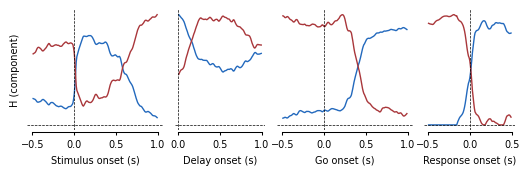

In [ ]:
# ====== Split H by phase lengths and plot (reference) ======
n_stim, n_delay, n_go, n_resp = [len(t) for t in time_vectors]
offsets = np.cumsum([0, n_stim, n_delay, n_go])
phase_slices = [
    ('stimulus', slice(offsets[0], offsets[1]), time_vectors[0], 'Stimulus onset (s)'),
    ('delay',    slice(offsets[1], offsets[2]), time_vectors[1], 'Delay onset (s)'),
    ('go',       slice(offsets[2], offsets[3]), time_vectors[2], 'Go onset (s)'),
    ('response', slice(offsets[3], offsets[3] + n_resp), time_vectors[3], 'Response onset (s)'),
]

fig, axes = plt.subplots(
    1, 4, figsize=(16 * cm, 4 * cm),
    gridspec_kw={'width_ratios': [n_stim, n_delay, n_go, n_resp]},
)
plt.subplots_adjust(wspace=0.1)

colors = sns.color_palette([blue, red, orange, green], n_components)

for ax, (phase, sl, time_vec, xlabel) in zip(axes, phase_slices):
    for comp_idx in range(n_components):
        ax.plot(
            time_vec, H[comp_idx, sl],
            color=colors[comp_idx], linewidth=1,
            label=f'comp{comp_idx + 1}',
        )
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    sns.despine(ax=ax, offset=1, trim=True)
    ax.set_yticklabels([])
    ax.set_yticks([])
    ax.spines['left'].set_visible(False)
    ax.set_xlabel(xlabel, fontsize=7)

axes[0].set_ylabel('H (component)', fontsize=7)
plt.show()
# Saved copy written after OUTPUT_DIR + helpers are defined (see reference-export cell below).

In [ ]:
# Legacy component-weighted trace — superseded by exploration section below.
pass

## Parameter exploration (optional grid)

Supplementary factorial over `k`, clip, sig, and desc. **Primary k justification is the model-selection section above.** Run on a **compute node** if executing the full grid. Outputs under `OUTPUT_DIR` (`../tmp/nmf/`); ends with `summary_all_variants.csv`.


In [ ]:
from IPython.display import display

OUTPUT_DIR = Path('../tmp/nmf')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Output dir: {OUTPUT_DIR.resolve()}')

COMP_K = [2, 3, 4]
CLIP_OPTS = [None, (1, 99)]
SIG_MODES = ['all_insula', 'sig_union', 'sig_per_phase']
DESC_OPTS = ['Repeat', 'all']

# Full factorial; set COMP_K=[2,3] or DESC_OPTS=['Repeat'] to shorten runtime
PARAM_GRID = [
    dict(k=k, clip=clip, sig=sig, desc=desc)
    for k in COMP_K
    for clip in CLIP_OPTS
    for sig in SIG_MODES
    for desc in DESC_OPTS
]
print(f'{len(PARAM_GRID)} variants in grid')


Output dir: /hpc/group/coganlab/nanlinshi/insula/tmp/nmf
36 variants in grid


In [ ]:
CLUSTER_COLORS = sns.color_palette([blue, red, orange, green], 4)


def variant_filename(k, clip, sig, desc):
    """Sanitized basename for saved figures/CSVs."""
    clip_s = 'none' if clip is None else f'{clip[0]}-{clip[1]}'
    return f'k{k}_clip-{clip_s}_sig-{sig}_desc-{desc}'


def agreement_aic_pic(meta, component):
    """Fraction of channels matching Hammers AIC/PIC under best component↔ROI assignment."""
    roi = meta['roi'].values
    valid = np.isin(roi, ['AIC', 'PIC'])
    if valid.sum() == 0:
        return np.nan
    comp = np.asarray(component)[valid]
    roi = roi[valid]
    ct = pd.crosstab(comp, roi)
    rois = [r for r in ['AIC', 'PIC'] if r in ct.columns]
    comps = sorted(ct.index.tolist())
    if len(rois) == 0 or len(comps) == 0:
        return np.nan
    mat = np.zeros((len(comps), len(rois)), dtype=float)
    for i, c in enumerate(comps):
        for j, r in enumerate(rois):
            mat[i, j] = ct.loc[c, r]
    if mat.size == 0:
        return np.nan
    from scipy.optimize import linear_sum_assignment
    row_ind, col_ind = linear_sum_assignment(-mat)
    return float(mat[row_ind, col_ind].sum() / len(comp))


def crosstab_counts(meta, component):
    return pd.crosstab(
        pd.Series(component, name='component'),
        meta['roi'].values,
        dropna=False,
    )


def plot_H(H, time_vectors, phase_names, *, n_components, title, save_path=None):
    n_times = [len(t) for t in time_vectors]
    offsets = np.cumsum([0] + n_times[:-1])
    xlabels = ['Stimulus', 'Delay', 'Go', 'Response']
    fig, axes = plt.subplots(
        1, len(phase_names), figsize=(4 * len(phase_names) * cm, 4 * cm),
        gridspec_kw={'width_ratios': n_times},
    )
    if len(phase_names) == 1:
        axes = [axes]
    colors = sns.color_palette([blue, red, orange, green], n_components)
    for i, (name, tvec) in enumerate(zip(phase_names, time_vectors)):
        ax = axes[i]
        sl = slice(offsets[i], offsets[i] + n_times[i])
        for c in range(n_components):
            ax.plot(tvec, H[c, sl], color=colors[c], lw=1, label=f'C{c + 1}')
        ax.axvline(0, color='k', ls='--', lw=0.5)
        ax.set_xlabel(f'{xlabels[i]} (s)', fontsize=fontsize)
        ax.tick_params(labelsize=fontsize)
        sns.despine(ax=ax, offset=1, trim=True)
    axes[0].set_ylabel('H', fontsize=fontsize)
    fig.suptitle(title, fontsize=fontsize, y=1.02)
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.close(fig)
    else:
        plt.show()


def plot_brain_scatter(meta, component, weight, *, title, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(10 * cm, 5 * cm))
    for ax, hemi, label in zip(axes, ['L', 'R'], ['Left', 'Right']):
        m = meta['hemi'] == hemi
        if not m.any():
            ax.set_visible(False)
            continue
        ax.scatter(
            meta.loc[m, 'y'], meta.loc[m, 'z'],
            c=[CLUSTER_COLORS[c] for c in component[m]],
            s=20 + 80 * (weight[m] / (weight[m].max() + 1e-9)),
            edgecolors='k', linewidths=0.3, alpha=0.85,
        )
        ax.set_xlabel('y (mm)', fontsize=fontsize)
        ax.set_ylabel('z (mm)', fontsize=fontsize)
        ax.set_title(label, fontsize=fontsize)
        ax.tick_params(labelsize=fontsize)
        sns.despine(ax=ax)
    fig.suptitle(title, fontsize=fontsize, y=1.02)
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.close(fig)
    else:
        plt.show()


def plot_roi_crosstab(meta, component, *, title, save_path=None, show_table=True):
    tab_counts = crosstab_counts(meta, component)
    tab = tab_counts.div(tab_counts.sum(axis=1), axis=0)
    fig, ax = plt.subplots(figsize=(5 * cm, 3.5 * cm))
    tab.plot(kind='bar', stacked=True, ax=ax, color=[blue, red], width=0.7)
    ax.set_ylabel('Fraction', fontsize=fontsize)
    ax.set_xlabel('NMF component', fontsize=fontsize)
    ax.tick_params(labelsize=fontsize)
    ax.legend(title='Hammers roi', fontsize=fontsize - 1, title_fontsize=fontsize - 1)
    ax.set_title(title, fontsize=fontsize)
    sns.despine(ax=ax)
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.close(fig)
    else:
        plt.show()
    if show_table:
        display(tab.round(3))
    return tab_counts


In [ ]:
# --- Save reference run (k=2, Repeat, sig_union) to OUTPUT_DIR ---
ref_tag = variant_filename(2, (1, 99), 'sig_union', 'Repeat')
ref_title = f'reference | {ref_tag}'
component_ref, weight_ref = assign_components(W)
plot_H(
    H, time_vectors, phase_names,
    n_components=n_components,
    title=ref_title,
    save_path=OUTPUT_DIR / f'{ref_tag}_H.png',
)
plot_brain_scatter(
    coords_ref, component_ref, weight_ref,
    title=ref_title,
    save_path=OUTPUT_DIR / f'{ref_tag}_scatter.png',
)
ref_ct = plot_roi_crosstab(
    coords_ref, component_ref,
    title=ref_title,
    save_path=OUTPUT_DIR / f'{ref_tag}_crosstab.png',
    show_table=False,
)
ref_ct.to_csv(OUTPUT_DIR / f'{ref_tag}_crosstab.csv')
print(f'Saved reference outputs with prefix {ref_tag}_*')


Saved reference outputs with prefix k2_clip-1-99_sig-sig_union_desc-Repeat_*


In [ ]:
# === Run parameter grid (compute node recommended) ===
summary_rows = []

for i, params in enumerate(PARAM_GRID):
    k, clip, sig, desc = params['k'], params['clip'], params['sig'], params['desc']
    tag = variant_filename(k, clip, sig, desc)
    title = f'k={k} | clip={clip} | sig={sig} | desc={desc}'
    print('\n' + '=' * 72)
    print(f'[{i + 1}/{len(PARAM_GRID)}] {title}')

    try:
        subset, meta = prepare_subset(HGAs, description=desc, sig_mode=sig)
        concat_stage, tvecs, pnames, meta = build_concat_stage(subset)
        n_ch = len(concat_stage.channel)
        n_tp = int(concat_stage.shape[1])
        if n_ch < k:
            print(f'  SKIP: only {n_ch} channels (< k={k})')
            continue
        W, H, _ = fit_nmf(concat_stage, n_components=k, clip_percentile=clip)
        component, weight = assign_components(W)
        meta = meta.copy()
        meta['component'] = component
        meta['weight'] = weight

        print(f'  channels={n_ch}, timepoints={n_tp}')
        plot_H(
            H, tvecs, pnames, n_components=k, title=title,
            save_path=OUTPUT_DIR / f'{tag}_H.png',
        )
        plot_brain_scatter(
            meta, component, weight, title=title,
            save_path=OUTPUT_DIR / f'{tag}_scatter.png',
        )
        ct = plot_roi_crosstab(
            meta, component, title=title,
            save_path=OUTPUT_DIR / f'{tag}_crosstab.png',
            show_table=False,
        )
        ct.to_csv(OUTPUT_DIR / f'{tag}_crosstab.csv')

        agreement = agreement_aic_pic(meta, component)
        row = dict(
            k=k,
            clip=str(clip),
            sig=sig,
            desc=desc,
            n_channels=n_ch,
            n_timepoints=n_tp,
            agreement_AIC_PIC=agreement,
        )
        for c in range(k):
            for roi in ['AIC', 'PIC']:
                row[f'comp{c}_{roi}'] = int(ct.loc[c, roi]) if c in ct.index and roi in ct.columns else 0
        summary_rows.append(row)
        print(f'  saved {tag}_* | agreement_AIC_PIC={agreement:.3f}' if pd.notna(agreement) else f'  saved {tag}_*')
    except Exception as exc:
        print(f'  ERROR: {exc}')
    finally:
        plt.close('all')

if summary_rows:
    summary_df = pd.DataFrame(summary_rows)
    summary_path = OUTPUT_DIR / 'summary_all_variants.csv'
    summary_df.to_csv(summary_path, index=False)
    print(f'\nWrote {len(summary_df)} rows -> {summary_path.resolve()}')
    display(summary_df.sort_values(['k', 'sig', 'desc', 'clip']).head(10))
else:
    print('No successful grid runs; summary CSV not written.')



[1/36] k=2 | clip=None | sig=all_insula | desc=Repeat
  channels=201, timepoints=636
  saved k2_clip-none_sig-all_insula_desc-Repeat_* | agreement_AIC_PIC=0.667

[2/36] k=2 | clip=None | sig=all_insula | desc=all
  channels=227, timepoints=636
  saved k2_clip-none_sig-all_insula_desc-all_* | agreement_AIC_PIC=0.683

[3/36] k=2 | clip=None | sig=sig_union | desc=Repeat
  channels=197, timepoints=636
  saved k2_clip-none_sig-sig_union_desc-Repeat_* | agreement_AIC_PIC=0.665

[4/36] k=2 | clip=None | sig=sig_union | desc=all
  channels=216, timepoints=636
  saved k2_clip-none_sig-sig_union_desc-all_* | agreement_AIC_PIC=0.685

[5/36] k=2 | clip=None | sig=sig_per_phase | desc=Repeat
  channels=196, timepoints=636
  saved k2_clip-none_sig-sig_per_phase_desc-Repeat_* | agreement_AIC_PIC=0.663

[6/36] k=2 | clip=None | sig=sig_per_phase | desc=all
  channels=215, timepoints=636
  saved k2_clip-none_sig-sig_per_phase_desc-all_* | agreement_AIC_PIC=0.684

[7/36] k=2 | clip=(1, 99) | sig=all_i

/hpc/home/ns458/miniconda3/envs/ieeg/lib/python3.11/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


  channels=227, timepoints=636
  saved k3_clip-none_sig-all_insula_desc-all_* | agreement_AIC_PIC=0.577

[15/36] k=3 | clip=None | sig=sig_union | desc=Repeat


/hpc/home/ns458/miniconda3/envs/ieeg/lib/python3.11/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


  channels=197, timepoints=636
  saved k3_clip-none_sig-sig_union_desc-Repeat_* | agreement_AIC_PIC=0.670

[16/36] k=3 | clip=None | sig=sig_union | desc=all
  channels=216, timepoints=636
  saved k3_clip-none_sig-sig_union_desc-all_* | agreement_AIC_PIC=0.560

[17/36] k=3 | clip=None | sig=sig_per_phase | desc=Repeat
  channels=196, timepoints=636
  saved k3_clip-none_sig-sig_per_phase_desc-Repeat_* | agreement_AIC_PIC=0.668

[18/36] k=3 | clip=None | sig=sig_per_phase | desc=all


...

/hpc/home/ns458/miniconda3/envs/ieeg/lib/python3.11/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


  channels=196, timepoints=636
  saved k4_clip-1-99_sig-sig_per_phase_desc-Repeat_* | agreement_AIC_PIC=0.469

[36/36] k=4 | clip=(1, 99) | sig=sig_per_phase | desc=all


/hpc/home/ns458/miniconda3/envs/ieeg/lib/python3.11/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


  channels=215, timepoints=636
  saved k4_clip-1-99_sig-sig_per_phase_desc-all_* | agreement_AIC_PIC=0.567

Wrote 36 rows -> /hpc/group/coganlab/nanlinshi/insula/tmp/nmf/summary_all_variants.csv


,k,clip,sig,desc,n_channels,n_timepoints,agreement_AIC_PIC,comp0_AIC,comp0_PIC,comp1_AIC,comp1_PIC,comp2_AIC,comp2_PIC,comp3_AIC,comp3_PIC
6,2,"(1, 99)",all_insula,Repeat,201,636,0.537313,101,64,29,7,NaN,NaN,NaN,NaN
0,2,None,all_insula,Repeat,201,636,0.666667,5,9,125,62,NaN,NaN,NaN,NaN
7,2,"(1, 99)",all_insula,all,227,636,0.519824,101,61,48,17,NaN,NaN,NaN,NaN
1,2,None,all_insula,all,227,636,0.682819,2,8,147,70,NaN,NaN,NaN,NaN
10,2,"(1, 99)",sig_per_phase,Repeat,196,636,0.535714,98,63,28,7,NaN,NaN,NaN,NaN
4,2,None,sig_per_phase,Repeat,196,636,0.663265,5,9,121,61,NaN,NaN,NaN,NaN
11,2,"(1, 99)",sig_per_phase,all,215,636,0.511628,96,61,44,14,NaN,NaN,NaN,NaN
5,2,None,sig_per_phase,all,215,636,0.683721,2,9,138,66,NaN,NaN,NaN,NaN
8,2,"(1, 99)",sig_union,Repeat,197,636,0.538071,99,63,28,7,NaN,NaN,NaN,NaN
2,2,None,sig_union,Repeat,197,636,0.664975,5,9,122,61,NaN,NaN,NaN,NaN


## Analysis guide (`tmp/nmf/`)

### Hammers (`../tmp/nmf/`)
1. **Pick k** — `kselect_clip-none_sig-sig_union_desc-all_metrics.csv` and `_model_selection.png`.
2. **k=2 brain maps** — `k2_clip-none_sig-sig_union_desc-all_brain_{nmf_weighted,nmf_minor_weight,hammers,sidebyside}.png`.
3. **Grid crosstabs** (optional) — `*_crosstab.csv` / `summary_all_variants.csv`.

### aparc (`../tmp/nmf/aparc/`)
1. **Pick k** — `aparc_kselect_clip-none_sig-sig_union_desc-all_metrics.csv` and `_model_selection.png`.
2. **k=2 brain maps** — `aparc_k2_clip-none_sig-sig_union_desc-all_brain_{nmf_weighted,nmf_minor_weight,aparc,sidebyside}.png`.
3. **Comparison** — `aparc_vs_hammers_comparison.csv` plus comparison cell crosstabs.

**Slurm brain render:** `sbatch scripts/slurm/nmf_brain_render.sh [hammers|aparc]`
